Recall Probability by Lag

Repeated items benefit from spacing: recall improves as more study items intervene between presentations. This notebook compares observed repetition-lag curves with a control dataset and lets you flip between binned and full-resolution views via the `mode` parameter.

Switch `mode` to `'full'` to examine every lag bucket individually.

Adjust `control_trial_query` to redefine the baseline control population.


In [1]:
import matplotlib.pyplot as plt
import os

from jaxcmr.analyses.rpl import (
    infer_max_lag,
    plot_full_rpl,
    plot_rpl,
    subject_binned_rpl,
    subject_full_rpl,
    test_rpl_slope,
    test_rpl_slope_vs_comparison,
    run_rpl_slope_analysis,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.repetition import make_control_dataset

def save_figure(figure_dir, figure_str, suffix=None):
    plt.tight_layout()
    if not figure_str:
        plt.show()
        return
    os.makedirs(figure_dir, exist_ok=True)
    suffix_str = f"_{suffix}" if suffix else ""
    figure_path = os.path.join(figure_dir, f"{figure_str}{suffix_str}.png")
    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()


In [2]:
data_path = "data/LohnasKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
mixed_trial_query = "data['list_type'] > 3"
control_trial_query = "data['list_type'] == 1"
control_shuffles = 10
mode = "full"  # options: 'binned', 'full'


In [3]:
# Parameters
data_path = "projects/repfr/results/simulations/LohnasKahana2014_BasePositionalCMRNoStop_rerun_best_of_1.h5"
figure_dir = "projects/repfr/results/figures/fitting"
figure_str = "LohnasKahana2014_BasePositionalCMRNoStop_rerun_best_of_1_rpl.png"
mixed_trial_query = "data['list_type'] > 3 "
control_trial_query = "data['list_type'] == 1"
control_shuffles = 1
ylim = [0.33, 0.7]


In [4]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)

data = load_data(data_path)
trial_mask = generate_trial_mask(data, mixed_trial_query)

control_dataset = make_control_dataset(data, mixed_trial_query, control_trial_query, control_shuffles)
control_mask = generate_trial_mask(control_dataset, mixed_trial_query)

datasets = [data, control_dataset]
masks = [trial_mask, control_mask]

max_lag = infer_max_lag(data["pres_itemnos"], data["pres_itemnos"].shape[1])
plotting_function = plot_rpl if mode == "binned" else plot_full_rpl
subject_function = subject_binned_rpl if mode == "binned" else subject_full_rpl



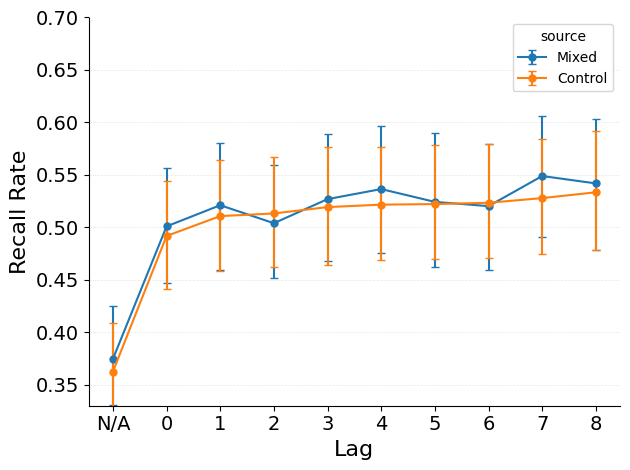

In [5]:

plotting_function(
    datasets, 
    masks, 
    labels=["Mixed", "Control"], 
    contrast_name="source"
);

if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)


In [6]:
observed_rpl = subject_function(data, trial_mask, max_lag)
control_rpl = subject_function(control_dataset, control_mask, max_lag)

observed_result = test_rpl_slope(observed_rpl, mode=mode)
control_result = test_rpl_slope(control_rpl, mode=mode)
comparison_result = test_rpl_slope_vs_comparison(observed_rpl, control_rpl, mode=mode)

print()
print("=" * 60)
print("Spacing Effect Slope: Observed")
print("=" * 60)
print("H0: The recall-probability-by-lag slope is 0.")
print(observed_result)

print()
print("=" * 60)
print("Spacing Effect Slope: Control")
print("=" * 60)
print("H0: The recall-probability-by-lag slope is 0.")
print(control_result)

print()
print("=" * 70)
print("Observed vs Control: Spacing Effect Slope")
print("=" * 70)
print("H0: The observed and control slopes are equal.")
print(comparison_result)



Spacing Effect Slope: Observed
H0: The recall-probability-by-lag slope is 0.
N=35
Mean slope: 0.0046
t-stat: 3.321 p=0.0022
W-stat: 110.0 p=0.0005

Spacing Effect Slope: Control
H0: The recall-probability-by-lag slope is 0.
N=35
Mean slope: 0.0040
t-stat: 7.103 p=0.0000
W-stat: 25.0 p=0.0000

Observed vs Control: Spacing Effect Slope
H0: The observed and control slopes are equal.
N=35
Mean slope (observed): 0.0046
Mean slope (comparison): 0.0040
Mean difference: 0.0006
t-stat: 0.464 p=0.6453
W-stat: 241.0 p=0.2318


In [7]:
observed_result_mode, control_result_mode, comparison_result_mode = run_rpl_slope_analysis(
    data,
    trial_mask,
    control_dataset,
    control_mask,
    mode=mode,
    max_lag=max_lag,
)

print()
print("=" * 60)
print("Spacing Effect Slope (Mode-Aware): Observed")
print("=" * 60)
print("H0: The recall-probability-by-lag slope is 0.")
print(observed_result_mode)

print()
print("=" * 60)
print("Spacing Effect Slope (Mode-Aware): Control")
print("=" * 60)
print("H0: The recall-probability-by-lag slope is 0.")
print(control_result_mode)

print()
print("=" * 70)
print("Observed vs Control (Mode-Aware): Spacing Effect Slope")
print("=" * 70)
print("H0: The observed and control slopes are equal.")
print(comparison_result_mode)



Spacing Effect Slope (Mode-Aware): Observed
H0: The recall-probability-by-lag slope is 0.
N=35
Mean slope: 0.0046
t-stat: 3.321 p=0.0022
W-stat: 110.0 p=0.0005

Spacing Effect Slope (Mode-Aware): Control
H0: The recall-probability-by-lag slope is 0.
N=35
Mean slope: 0.0040
t-stat: 7.103 p=0.0000
W-stat: 25.0 p=0.0000

Observed vs Control (Mode-Aware): Spacing Effect Slope
H0: The observed and control slopes are equal.
N=35
Mean slope (observed): 0.0046
Mean slope (comparison): 0.0040
Mean difference: 0.0006
t-stat: 0.464 p=0.6453
W-stat: 241.0 p=0.2318
